U/t=8, W_L(g=0)=0.66120810, Delta range=[0.00000, 0.36034]
U/t=16, W_L(g=0)=0.65853666, Delta range=[0.00000, 0.30757]
U/t=32, W_L(g=0)=0.65831369, Delta range=[0.00000, 0.28822]
64.94676518440247 seconds


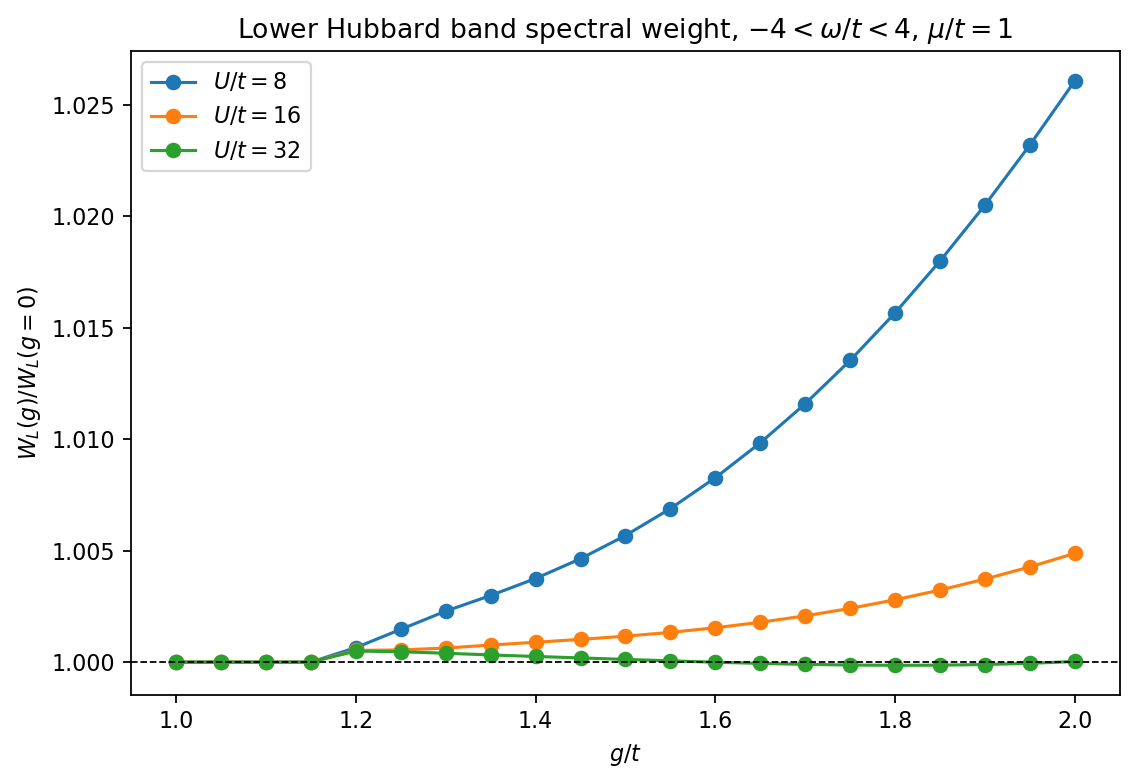

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import optimize

start_time = time.time()
def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_ku, n_kd, n_-ku, n_-kd> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def block_matrix_elements(xi_k, U, Delta):
    """
    Construct the explicit block matrices derived from s_z and momentum
    conservation.

    Basis convention:
        |n_ku, n_kd, n_-ku, n_-kd>

    Mode order:
        0: k up
        1: k down
        2: -k up
        3: -k down
    """
    d = Delta
    dc = np.conjugate(Delta)

    h_sz_2 = np.array([[2.0 * xi_k]], dtype=complex)
    basis_sz_2 = [(1, 0, 1, 0)]

    h_sz_minus_2 = np.array([[2.0 * xi_k]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 0, 1)]

    h1 = np.array(
        [
            [xi_k, -dc],
            [-d, 3.0 * xi_k + U],
        ],
        dtype=complex,
    )

    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 1, 0)]
    basis_sz_1_b = [(0, 0, 1, 0), (1, 0, 1, 1)]

    basis_sz_minus_1_a = [(0, 1, 0, 0), (1, 1, 0, 1)]
    basis_sz_minus_1_b = [(0, 0, 0, 1), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, -dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [-d, 0.0, 2.0 * xi_k, dc],
            [0.0, -d, d, 4.0 * xi_k + 2.0 * U],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 0, 1),
        (0, 1, 1, 0),
        (1, 1, 1, 1),
    ]

    h_doublon = np.array([[2.0 * xi_k + U]], dtype=complex)
    basis_doublon_k = [(1, 1, 0, 0)]
    basis_doublon_minus_k = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h1, basis_sz_1_a),
        (h1, basis_sz_1_b),
        (h_sz_0_4, basis_sz_0_4),
        (h_doublon, basis_doublon_k),
        (h_doublon, basis_doublon_minus_k),
        (h1, basis_sz_minus_1_a),
        (h1, basis_sz_minus_1_b),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(k, t, mu, U, Delta):
    """
    Diagonalize all blocks and embed their eigenvectors into the full
    16-dimensional occupation basis.
    """
    epsilon_k = -2.0 * t * np.cos(k)
    xi_k = epsilon_k - mu

    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(xi_k, U, Delta):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """Return c operators and B = b_k + b_-k in the full occupation basis."""
    c = [annihilation_operator(i) for i in range(4)]
    b_total = c[3] @ c[0] + c[1] @ c[2]
    return c, b_total


def pair_expectation_block(k, t, mu, U, Delta, beta):
    """Thermal expectation value of b_k + b_-k using block diagonalization."""
    energies, vectors = diagonalize_sector_block(k, t, mu, U, Delta)
    _, b_total = sector_operators()

    rho = thermal_weights(energies, beta)
    b_eigenbasis = vectors.conj().T @ b_total @ vectors
    return np.sum(rho * np.diag(b_eigenbasis))


def solve_gap_block(k_positive, g, t, mu, U, beta, initial_delta=0.5, mixing=0.5, max_iter=200, tol=1e-10):
    """
    Solve the self-consistent gap equation with scipy.optimize.root_scalar.

    We solve

        new_delta(delta) - delta = 0,

    where

        new_delta(delta) = -g * 0.5 * mean_{k>0} <b_k + b_-k>_delta.

    The arguments mixing and max_iter are kept for compatibility with older
    calls, but root_scalar does not use them.
    """

    def new_delta(delta):
        pair_avg = 0.5 * np.mean(
            [pair_expectation_block(k, t, mu, U, delta, beta) for k in k_positive]
        )
        return float(np.real(-g * pair_avg))

    def gap_equation(delta):
        return new_delta(delta) - delta

    # Delta = 0 is always a solution. Search on the positive side for a
    # nonzero superconducting root.
    lower = 1e-10
    upper = max(abs(float(np.real(initial_delta))), 1e-4)
    max_upper = max(8.0 * abs(g), 8.0, upper)

    f_lower = gap_equation(lower)
    f_upper = gap_equation(upper)

    while f_lower * f_upper > 0.0 and upper < max_upper:
        upper *= 2.0
        f_upper = gap_equation(upper)

    if f_lower * f_upper > 0.0:
        return 0.0 + 0.0j

    result = optimize.root_scalar(gap_equation, bracket=(lower, upper), xtol=tol, rtol=tol)
    if not result.converged:
        return 0.0 + 0.0j

    return complex(result.root)


def spectral_function_for_k_block(k, omega_values, t, mu, U, Delta, beta, gamma, spin="up"):
    """
    Compute A_sigma(k, omega) using A = A_plus + A_minus and block
    diagonalization.
    """
    energies, vectors = diagonalize_sector_block(abs(k), t, mu, U, Delta)
    c, _ = sector_operators()
    rho = thermal_weights(energies, beta)

    mode = 0 if spin == "up" else 1
    c_op = c[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def hk_superconducting_spectral_function_block(
    k_values,
    omega_values,
    t=1.0,
    mu=1.0,
    U=8.0,
    Delta=0.8,
    beta=50.0,
    gamma=0.06,
    spin="up",
):
    spectral_weight = np.zeros((len(omega_values), len(k_values)), dtype=float)

    for i, k in enumerate(k_values):
        spectral_weight[:, i] = spectral_function_for_k_block(
            k,
            omega_values,
            t=t,
            mu=mu,
            U=U,
            Delta=Delta,
            beta=beta,
            gamma=gamma,
            spin=spin,
        )

    return spectral_weight


def lorentzian_integral_below(center, gamma, omega_cut=0.0):
    """
    Integral of L(omega - center) from -infinity to omega_cut.

    L(x) = gamma / pi / (x^2 + gamma^2).
    """
    return 0.5 + np.arctan((omega_cut - center) / gamma) / np.pi


def lorentzian_integral_window(center, gamma, omega_min, omega_max):
    """Integral of a normalized Lorentzian from omega_min to omega_max."""
    return (
        lorentzian_integral_below(center, gamma, omega_cut=omega_max)
        - lorentzian_integral_below(center, gamma, omega_cut=omega_min)
    )


def integrated_window_weight_for_k_block(
    k,
    t,
    mu,
    U,
    Delta,
    beta,
    gamma,
    omega_min,
    omega_max,
    spin="up",
):
    """
    Compute integral_{omega_min}^{omega_max} A_sigma(k, omega) d omega
    directly from the Lehmann representation with Lorentzian broadening.
    """
    energies, vectors = diagonalize_sector_block(abs(k), t, mu, U, Delta)
    c, _ = sector_operators()
    rho = thermal_weights(energies, beta)

    mode = 0 if spin == "up" else 1
    c_op = c[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    weight = 0.0
    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            addition_center = e_n - e_m
            removal_center = -(e_n - e_m)

            weight += addition_weight * lorentzian_integral_window(
                addition_center, gamma, omega_min, omega_max
            )
            weight += removal_weight * lorentzian_integral_window(
                removal_center, gamma, omega_min, omega_max
            )

    return float(np.real(weight))


def integrated_window_weight_bz_average(
    k_values,
    t,
    mu,
    U,
    Delta,
    beta,
    gamma,
    omega_min,
    omega_max,
    spin="up",
):
    """Brillouin-zone average of spectral weight in an omega window."""
    weight_per_k = np.array(
        [
            integrated_window_weight_for_k_block(
                k,
                t=t,
                mu=mu,
                U=U,
                Delta=Delta,
                beta=beta,
                gamma=gamma,
                omega_min=omega_min,
                omega_max=omega_max,
                spin=spin,
            )
            for k in k_values
        ]
    )
    total_weight = np.trapz(weight_per_k, k_values) / (k_values[-1] - k_values[0])
    return weight_per_k, total_weight


# Model and plotting parameters for Fig. 3c-like lower Hubbard band weight.
t = 1.0
mu = 1.0
beta = 1000.0
gamma = 0.06
spin = "up"
initial_delta = 0.8

U_values = [8.0, 16.0, 32.0]
g_values = np.linspace(1.0, 2.0, 21)
omega_min = -4.0
omega_max = 4.0

nk = 401
k_values = np.linspace(-np.pi, np.pi, nk)
k_positive = np.linspace(0.0, np.pi, 161)[1:-1]

plt.figure(figsize=(7.2, 5.0), dpi=160)

for U in U_values:
    # Fig. 3c compares the integrated lower Hubbard band weight to its g=0
    # value. The caption uses the window -4 < omega/t < 4 at mu/t = 1.
    _, normal_weight = integrated_window_weight_bz_average(
        k_values,
        t=t,
        mu=mu,
        U=U,
        Delta=0.0,
        beta=beta,
        gamma=gamma,
        omega_min=omega_min,
        omega_max=omega_max,
        spin=spin,
    )

    ratios = []
    gaps = []
    for g in g_values:
        Delta = solve_gap_block(
            k_positive,
            g=g,
            t=t,
            mu=mu,
            U=U,
            beta=beta,
            initial_delta=initial_delta,
        )
        _, sc_weight = integrated_window_weight_bz_average(
            k_values,
            t=t,
            mu=mu,
            U=U,
            Delta=Delta,
            beta=beta,
            gamma=gamma,
            omega_min=omega_min,
            omega_max=omega_max,
            spin=spin,
        )

        ratios.append(sc_weight / normal_weight)
        gaps.append(Delta.real)

    plt.plot(g_values, ratios, marker="o", linewidth=1.4, label=rf"$U/t={U:g}$")
    print(
        f"U/t={U:g}, W_L(g=0)={normal_weight:.8f}, "
        f"Delta range=[{min(gaps):.5f}, {max(gaps):.5f}]"
    )

plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel(r"$g/t$")
plt.ylabel(r"$W_L(g)/W_L(g=0)$")
plt.title(
    rf"Lower Hubbard band spectral weight, ${omega_min:g}<\omega/t<{omega_max:g}$, "
    rf"$\mu/t={mu:g}$"
)
plt.legend()

plt.tight_layout()
# plt.savefig("hk_lower_hubbard_weight_fig3c.png", bbox_inches="tight")
# plt.close()

end_time = time.time()
print(end_time - start_time, "seconds")
